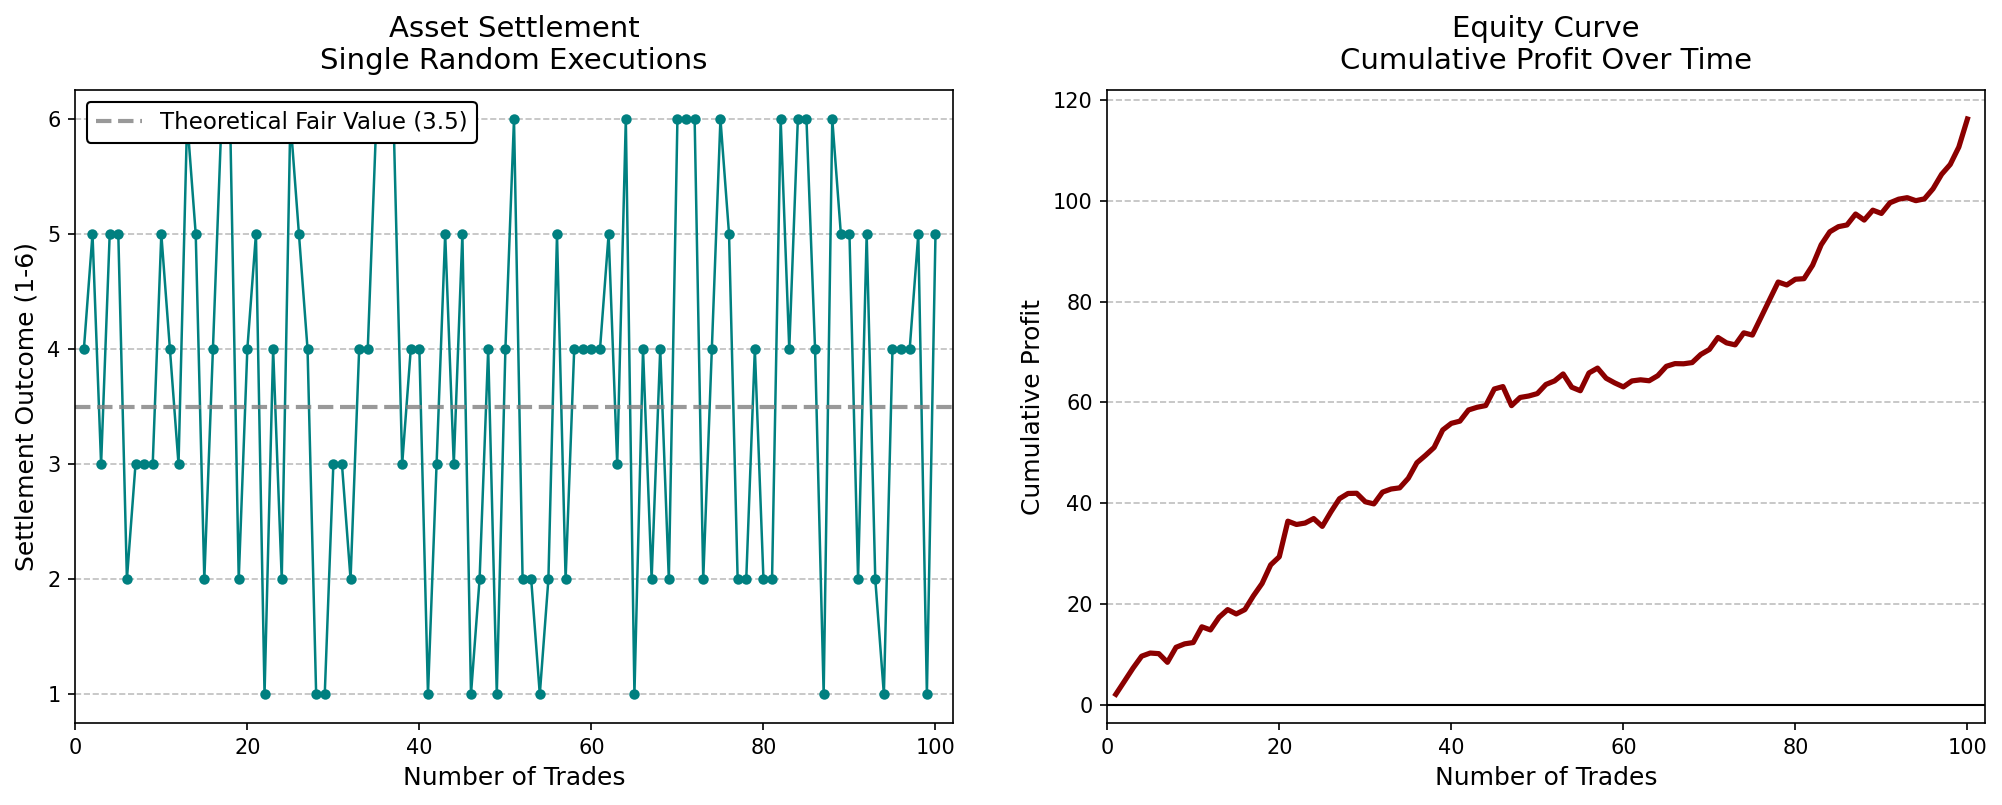

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Figure 1.6(b-c) — Asset settlement and equity curve
# This notebook simulates random asset settlements and a cumulative profit curve
# It is used as an illustrative stationary market-making example in Chapter 1

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set the random seed to make the simulation reproducible
np.random.seed(42)

n_trades = 100
trades = np.arange(1, n_trades + 1)

# Simulate asset settlement outcomes from a discrete uniform distribution
settlements = np.random.randint(1, 7, size=n_trades)

# Simulate the cumulative equity curve
edge_per_trade = 1.0
noise = np.random.normal(loc=edge_per_trade, scale=1.8, size=n_trades)
equity_curve = np.cumsum(noise)

# Figure construction with two side-by-side panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Panel 1: asset settlement
ax1.plot(
    trades,
    settlements,
    marker="o",
    markersize=4,
    linestyle="-",
    color="teal",
    linewidth=1.2
)

ax1.axhline(
    3.5,
    color="gray",
    linestyle="--",
    alpha=0.8,
    linewidth=2,
    label="Theoretical Fair Value (3.5)"
)

ax1.set_title(
    "Asset Settlement\nSingle Random Executions",
    fontsize=14,
    pad=10
)
ax1.set_xlabel("Number of Trades", fontsize=12)
ax1.set_ylabel("Settlement Outcome (1-6)", fontsize=12)
ax1.set_yticks(range(1, 7))
ax1.set_xlim(0, n_trades + 2)

ax1.legend(
    fontsize=11,
    loc="upper left",
    frameon=True,
    framealpha=1,
    edgecolor="black"
)

# Panel 2: cumulative equity curve
ax2.plot(
    trades,
    equity_curve,
    color="darkred",
    linewidth=2.5
)

ax2.axhline(0, color="black", linewidth=1)

ax2.set_title(
    "Equity Curve\nCumulative Profit Over Time",
    fontsize=14,
    pad=10
)
ax2.set_xlabel("Number of Trades", fontsize=12)
ax2.set_ylabel("Cumulative Profit", fontsize=12)
ax2.set_xlim(0, n_trades + 2)

for ax in [ax1, ax2]:
    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.5)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

# Export figure for the thesis
plt.tight_layout(pad=3.0)
output_path = OUTPUT_DIR / "fig_1_6bc_asset_equity.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()